# Calibration Curves by Subject

Visualize isotonic vs. kernel-smoothed reliability curves. Identify subjects where the monotonicity assumption diverges from the unconstrained fit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = 'gpt4o'  # or 'llama'
curves = pd.read_parquet(f'../data/processed/calibration_curves_{MODEL}.parquet')
summaries = pd.read_parquet(f'../data/processed/subject_summaries_{MODEL}.parquet')
summaries.head(10)

,subject,domain,n,ece,mean_gap,mean_confidence,mean_accuracy
0,moral_scenarios,Humanities,895,0.486487,0.486487,0.923359,0.436872
1,virology,Other,166,0.426856,0.437287,0.967408,0.530120
2,abstract_algebra,STEM,100,0.420346,0.470346,0.850346,0.380000
3,global_facts,Other,100,0.415333,0.412673,0.912673,0.500000
4,formal_logic,Humanities,126,0.389728,0.405307,0.937053,0.531746
5,professional_law,Humanities,1534,0.375907,0.375907,0.950223,0.574316
6,machine_learning,STEM,112,0.374099,0.367358,0.956643,0.589286
7,college_chemistry,STEM,100,0.358105,0.345595,0.875595,0.530000
8,college_physics,STEM,102,0.351777,0.358278,0.897494,0.539216
9,econometrics,Social Sciences,114,0.324389,0.317748,0.958099,0.640351


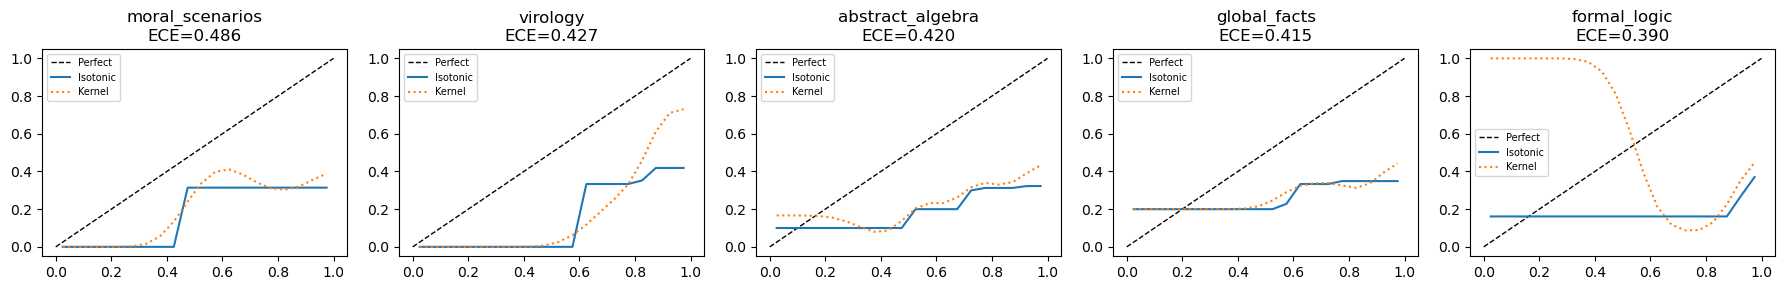

In [2]:
def plot_curve(row, ax):
    bins = np.array(row['confidence_bins'])
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
    ax.plot(bins, row['isotonic_acc'], label='Isotonic')
    ax.plot(bins, row['kernel_acc'], label='Kernel', linestyle=':')
    ax.set_title(f"{row['subject']}\nECE={row['ece']:.3f}")
    ax.legend(fontsize=7)

# Plot top-5 most miscalibrated subjects
top5 = curves.nlargest(5, 'ece')
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, (_, row) in zip(axes, top5.iterrows()):
    plot_curve(row, ax)
plt.tight_layout()
plt.savefig(f'../report/figures/top5_miscalibrated_{MODEL}.pdf', bbox_inches='tight')